[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/StructuralRL/SRL/blob/main/tutorials/01_household_jax.ipynb)

**Running on Colab?** Just run the setup cell below. It clones the repo and installs the package. For a free GPU: Runtime → Change runtime type → GPU.

In [8]:
# --- Colab setup (auto-injected by build_notebooks.py; do not edit the .ipynb) ---
import os, sys, subprocess

if "google.colab" in sys.modules and os.path.basename(os.getcwd()) != "tutorials":
    # Clone the repo (this also brings calibration.py and the data/ reference
    # files the notebooks load) and install the package.
    if not os.path.isdir("SRL"):
        url = "https://github.com/StructuralRL/SRL.git"
        subprocess.run(["git", "clone", "--depth=1", url, "SRL"], check=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--no-deps", "-e", "SRL"], check=True)
    # --no-deps: Colab already ships jax (with its matched GPU plugin), optax,
    # numpy, scipy, matplotlib, and tqdm. Installing our pinned jax here would
    # desync it from the preinstalled GPU plugin and crash GPU runtimes.
    # Import srl straight from the clone. A mid-session `pip install -e`
    # registers the package only through a .pth file that Python reads at
    # startup, so it does not take effect in the already-running Colab
    # kernel. Putting the repo root on sys.path makes `import srl` work now.
    sys.path.insert(0, os.path.abspath("SRL"))
    os.chdir("SRL/tutorials")
    sys.path.insert(0, os.getcwd())

# 1. The same problem, in JAX

In notebook 0 we solved the income-fluctuation problem by value function
iteration in plain NumPy, and saved the answer. This notebook solves the same
model with the same method, VFI, but re-expressed in JAX. Nothing about the
economics changes. The only new thing is the *tooling*.

Why bother? Because the rest of the course runs on JAX: the policy gradient
(notebook 2) needs automatic differentiation, and the general-equilibrium
solver (notebooks 4–5) needs `jit` and `vmap` to be fast. Before we trust JAX
on a problem we *can't* check by hand, we introduce it on one we already
solved, and confirm it lands on the same consumption policy.

We change one axis only: NumPy → JAX. The model is held fixed. By the end you
will have (i) a JAX mental model, (ii) the household VFI written with
`vmap`/`jit`, (iii) a first look at `grad`, the object notebook 2 is built on,
and (iv) the same solver packaged as `srl`'s `VFISolver`.

## What you should already know

- **Notebook 0.** We reproduce its consumption policy, so it is the reference.
- The consumption–savings problem and value function iteration (from nb 0).

No JAX is assumed. This notebook *is* the JAX introduction. If you have never
written a line of JAX, you are in the right place.

## What JAX *is*: one idea, not three tools

It is tempting to learn JAX as a list of features: "there's `grad`, there's
`jit`, there's `vmap`." That list is exactly what makes JAX feel arbitrary.
Here is the single idea underneath all of it:

> **JAX is NumPy, plus the ability to transform functions. A *transformation*
> takes a function and returns a new function.**

You already know one transformation: **differentiation**. If $f(x)=x^2$, its
derivative is not a number, it is *another function*, $x\mapsto 2x$, that you
can evaluate anywhere. JAX's `grad` is literally that operator, as code:
`grad(f)` hands you back a new function. The other two transforms are the same
*shape* of thing:

- **`grad`**: a function $\mapsto$ the function that computes its derivative,
  the $\partial$ operator you already use.
- **`vmap`**: a function written for *one* input $\mapsto$ one that runs over a
  whole *batch*, the loop over your state grid, written for you.
- **`jit`**: a function $\mapsto$ the same function, compiled to one fast, fused
  machine-code kernel.

All three have the same type, **function in, function out**, and that is the
whole point: **they compose.** `jit(vmap(grad(f)))` is a compiled, batched
gradient. A table of three separate tools hides this; the composition *is* JAX.

In [9]:
import os

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

# Floats are 32-bit by default in JAX (speed on GPUs/TPUs). We want the JAX
# answer to match notebook 0's NumPy (which is 64-bit) to machine precision,
# that's the whole point of "same algorithm, different engine", so flip on x64.
jax.config.update("jax_enable_x64", True)

print("JAX devices:", jax.devices())

JAX devices: [CudaDevice(id=0), CudaDevice(id=1), CudaDevice(id=2), CudaDevice(id=3), CudaDevice(id=4), CudaDevice(id=5), CudaDevice(id=6), CudaDevice(id=7)]


Let's make "a transformation returns a function" concrete. `grad` applied to a
cubic returns its derivative *function*; apply `grad` again and you
differentiate *that* function in turn. And because the result is just another
function, `vmap` can lift it over a whole batch of inputs, composition in
action:

In [10]:
f = lambda x: x ** 3
df = jax.grad(f)              # df is a FUNCTION (x -> 3x^2), same kind of thing as f
d2f = jax.grad(df)           # transform it again: d2f is x -> 6x
print("f(2)=", f(2.0), " f'(2)=", df(2.0), " f''(2)=", d2f(2.0))
print("f' over a batch:", jax.vmap(df)(jnp.array([1.0, 2.0, 3.0])))  # vmap(grad(f))

f(2)= 8.0  f'(2)= 12.0  f''(2)= 12.0
f' over a batch: [ 3. 12. 27.]


## The one mechanism behind all of it: *tracing*

How can `grad`/`jit`/`vmap` rewrite a function they know nothing about? They
**trace** it. When you transform a function, JAX runs it *once* with fake
placeholder inputs ("tracers") that **record each operation instead of
computing numbers**. That recording is what gets differentiated, vectorized, or
compiled. Your Python body is a *recipe-builder*, run once on stand-ins; it is
not the computation itself.

This one fact, seen once, explains every surprising thing about JAX. Watch:

In [11]:
@jax.jit
def g(x):
    print("  >> python body running, x =", x)   # a side effect
    return x * 2

print("first call:")
_ = g(3.0)          # the body runs, but x prints as a *tracer*, not 3.0
print("second call:")
_ = g(4.0)          # the body does NOT run: JAX reuses the compiled recipe

first call:
  >> python body running, x = JitTracer(~float64[])
second call:


Two things just happened, and they are the Rosetta Stone for JAX:

1. `x` printed as a **tracer** (here `JitTracer(~float64[])`), not `3.0`. At trace time there
   are no values yet, `x` stands in for "some float," so your code runs at the
   level of shapes and dtypes, not numbers.
2. The second call printed **nothing**. The Python body ran *once* to build the
   recipe; after that, calls execute the compiled recipe and never re-enter
   your Python.

Hold those two phases apart, *Python builds a recipe (once, on tracers)* vs.
*the recipe computes numbers (many times, compiled)*, and JAX's "rules" stop
being arbitrary. They are all **consequences of tracing**:

- **Arrays are immutable**: `y = x.at[i].set(v)` returns a *new* array rather
  than writing in place, because an in-place mutation is a side effect the
  recipe cannot faithfully record.
- **Functions must be pure**: only operations on tracers are recorded; a
  `print`, or a read of a mutable global, is captured once or dropped, never
  re-run. (That is why the `print` above fired only on the first call.)
- **Shapes are static, values are not**: a tracer knows shape and dtype but no
  value, so `if c > 0:` on an array (or an output whose *size* depends on the
  data) cannot be traced. You write `jnp.where(c > 0, ...)` instead, an idiom
  you'll meet in the Bellman update below.

**See it for yourself.** `jax.make_jaxpr` prints the recorded recipe. Two
things to notice: the `print` inside is *nowhere* in the recipe (side effects
are not part of the computation), and the `.at[0].set` appears as an operation
that *produces a new array* rather than a mutation.

In [12]:
def recipe(v):
    print("(this line runs only while tracing)")
    return v.at[0].set(99.0).sum()

print(jax.make_jaxpr(recipe)(jnp.arange(4.0)))

(this line runs only while tracing)
{ lambda ; a:f64[4]. let
    b:i32[1] = broadcast_in_dim 0:i32[]
    c:f64[4] = scatter[
      dimension_numbers=ScatterDimensionNumbers(update_window_dims=(), inserted_window_dims=(0,), scatter_dims_to_operand_dims=(0,), operand_batching_dims=(), scatter_indices_batching_dims=())
      indices_are_sorted=True
      mode=GatherScatterMode.FILL_OR_DROP
      unique_indices=True
      update_consts=()
      update_jaxpr=None
    ] a b 99.0:f64[]
    d:f64[] = reduce_sum[axes=(0,) out_sharding=None] c
  in (d,) }


That is the whole mental model. In the value function iteration below you will
see each transformation in use: we write the Bellman objective for a single
state `(b, y)`, `vmap` it across the entire grid (the double loop, done by the
library), and `jit` the result (compile once, iterate cheaply). `grad` we only
*preview* here; it becomes the engine of notebook 2.

## The model, recalled from notebook 0

A household maximizes $\mathbb{E}_0\sum_t \beta^t u(c_t)$ with
$u(c)=c^{1-\sigma}/(1-\sigma)$, subject to $c + q\,b' = b + y$ and $b'\ge 0$,
taking the fixed bond price $q$ as given. The Bellman equation is
$$V(b,y) = \max_{s\in[0,1]}\ u\!\big(s\,(b+y)\big)
           + \beta \sum_{y'} \Pi(y'\mid y)\, V(b', y'),
  \qquad b' = (b+y-s(b+y))/q.$$

Rather than rebuild the calibration, we load notebook 0's saved grids and
parameters (same income process, same asset grid, same prices) so the two
solutions are comparable by construction. (Notebook 0 wrote this file.)

In [13]:
from calibration import SIGMA, BETA, Q_FIXED   # the one shared calibration (see calibration.py)

sigma, beta, q = SIGMA, BETA, Q_FIXED

_here = os.path.dirname(__file__) if "__file__" in globals() else "."
ref = np.load(os.path.join(_here, "data", "nb0_reference.npz"))

b_grid = jnp.asarray(ref["b_grid"])          # (n_b,)  asset grid, dense near 0
e_grid = jnp.asarray(ref["e_grid"])          # (n_y,)  income states
Pi = jnp.asarray(ref["Pi"])                  # (n_y, n_y) income transition
c_policy_np = ref["c_policy"]                # (n_b, n_y) the nb-0 reference policy

n_b, n_y = b_grid.shape[0], e_grid.shape[0]
n_s = 2000           # consumption-share choices (matches notebook 0)
eps = 1e-9           # consumption floor

print(f"n_b={n_b}, n_y={n_y};  sigma={sigma}, beta={beta}, q={q}")
print("income states:", np.asarray(e_grid).round(3))

n_b=100, n_y=3;  sigma=2.0, beta=0.98, q=0.995
income states: [0.436 0.885 1.794]


## Value function iteration, in JAX

Here is the one new idea, applied. We write the Bellman update as a **pure
function of a single state** `(b, y)`, then use `vmap` to apply it across the
entire grid (no nested Python loops over `b` and `y`) and `jit` to compile the
result. This is the JAX idiom: *write the scalar case, then vectorize and
compile it.*

The continuation value $V(b', y')$ is needed at an off-grid point $b'$, so we
interpolate it linearly on the asset grid with `jnp.interp`, exactly the scheme
notebook 0 used (`np.interp`), which is why the answers will match.

In [14]:
%%time

shares = jnp.linspace(0.0, 1.0, n_s)                 # candidate consumption shares
wealth = b_grid[:, None] + e_grid[None, :]           # cash on hand, (n_b, n_y)


def crra(c):
    """CRRA flow utility, matching notebook 0 (log at sigma == 1)."""
    cc = jnp.maximum(c, eps)
    if sigma == 1.0:
        return jnp.log(cc)
    return cc ** (1 - sigma) / (1 - sigma)


def objective_at_state(b, y_idx, V):
    """Bellman objective at one state (b, y), for every consumption share.

    Returns the vector u(c) + beta * E[V(b', y')] over the share grid, shape
    (n_s,). The max of this vector is V(b, y); its argmax is the policy.
    """
    w = b + e_grid[y_idx]                             # cash on hand (scalar)
    c = jnp.clip(w * shares, eps, w - eps)            # (n_s,)
    b_next = (w - c) / q                              # (n_s,)
    # Interpolate V(., y') at b_next for each y', then take the Pi-expectation.
    V_interp = jax.vmap(lambda col: jnp.interp(b_next, b_grid, col),
                        in_axes=1, out_axes=1)(V)     # (n_s, n_y')
    EV = V_interp @ Pi[y_idx]                         # (n_s,)
    return crra(c) + beta * EV


# vmap the single-state objective over y, then over b -> (n_b, n_y, n_s).
_obj_over_y = jax.vmap(objective_at_state, in_axes=(None, 0, None))
_obj_grid = jax.vmap(_obj_over_y, in_axes=(0, None, None))


@jax.jit
def bellman_step(V):
    """One application of the Bellman operator over the whole grid."""
    return _obj_grid(b_grid, jnp.arange(n_y), V).max(axis=-1)


def solve_vfi_jax(tol=1e-9, max_iter=5000):
    V = jnp.zeros((n_b, n_y))
    for it in range(max_iter):
        V_new = bellman_step(V)
        if jnp.max(jnp.abs(V_new - V)) < tol:
            V = V_new
            break
        V = V_new
    # Recover the consumption policy from the converged value function.
    obj = _obj_grid(b_grid, jnp.arange(n_y), V)       # (n_b, n_y, n_s)
    best = obj.argmax(axis=-1)                         # (n_b, n_y)
    c_policy = jnp.clip(wealth * shares[best], eps, wealth - eps)
    print(f"JAX VFI converged in {it} iterations")
    return V, c_policy


V_jax, c_policy_jax = solve_vfi_jax()

JAX VFI converged in 1036 iterations
CPU times: user 3.24 s, sys: 462 ms, total: 3.7 s
Wall time: 4.04 s


### Does it match notebook 0?

Same model, same method, different engine, so the consumption policies must
agree. We overlay the JAX policy (dashed) on the NumPy baseline (solid), and
report the largest discrepancy.

max |c_JAX - c_NumPy| = 0.00e+00


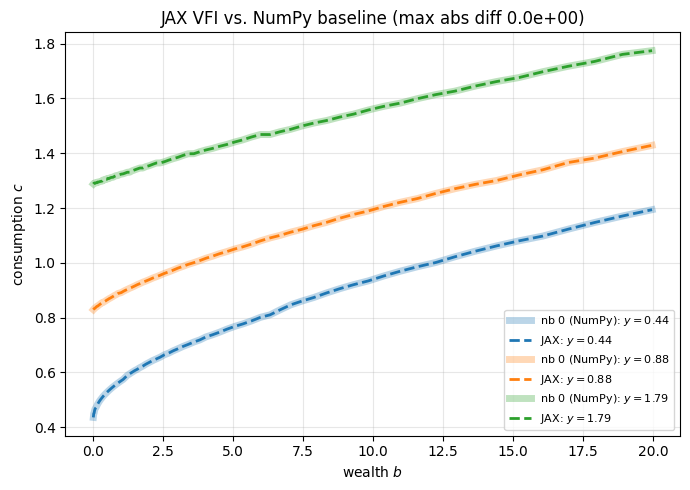

In [15]:
max_abs = float(jnp.max(jnp.abs(c_policy_jax - jnp.asarray(c_policy_np))))
print(f"max |c_JAX - c_NumPy| = {max_abs:.2e}")

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.asarray(b_grid) <= 20
for j in range(n_y):
    line, = ax.plot(b_grid[mask], c_policy_np[mask, j], lw=5, alpha=0.3,
                    label=f"nb 0 (NumPy): $y={float(e_grid[j]):.2f}$")
    ax.plot(b_grid[mask], c_policy_jax[mask, j], lw=2, ls="--", color=line.get_color(),
            label=f"JAX: $y={float(e_grid[j]):.2f}$")
ax.set_xlabel("wealth $b$")
ax.set_ylabel("consumption $c$")
ax.set_title(f"JAX VFI vs. NumPy baseline (max abs diff {max_abs:.1e})")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Indistinguishable. We now trust the JAX tooling on familiar ground.

## A first look at `grad`, pointed at this model

We met `grad` in the intro; here we aim it at the object that matters
economically, the utility function, and *verify* it, so we trust autodiff
before it carries the method in notebook 2. `jax.grad(u)` returns the exact
marginal-utility function; we check it against both the analytic derivative
$u'(c)=c^{-\sigma}$ and a finite-difference estimate. Notebook 2 replaces
"differentiate utility" with "differentiate *lifetime* utility with respect to
the policy", and *that* is the policy gradient.

In [16]:
u = lambda c: c ** (1 - sigma) / (1 - sigma)
du = jax.grad(u)                                      # exact derivative, via autodiff

c0 = 2.0
h = 1e-5
fd = (u(c0 + h) - u(c0 - h)) / (2 * h)
print(f"grad(u)({c0})      = {float(du(c0)):.8f}")
print(f"analytic c^-sigma  = {c0 ** (-sigma):.8f}")
print(f"finite difference  = {fd:.8f}")

grad(u)(2.0)      = 0.25000000
analytic c^-sigma  = 0.25000000
finite difference  = 0.25000000


## The same solver, packaged: `srl.VFISolver`

What we wrote by hand above (iterate the Bellman operator, vmapped over the
state grid) is exactly what `srl`'s `VFISolver` does. The library factors out
the loop and the vectorization; you supply a `transition_func` describing the
one-step economics. This is our first `srl` import, and the interface
(`state_space`, `action_space`, `transition_func`) recurs throughout the
course.

In [17]:
%%time

from srl import VFISolver
from srl.utils.safe_linalg import crra_util_func, interp_two_point_nonuniform

n_action = n_s                       # same action-grid resolution as the hand-port
c_grid = jnp.linspace(0.0, 1.0, n_action)


def transition_func(state_indices, a_idx, V):
    """One-step economics for VFISolver: (state, action, V) -> (E[V'], reward).

    The same Bellman recursion as above, now as a callback the solver drives.
    """
    b_idx, y_idx = state_indices
    w = b_grid[b_idx] + e_grid[y_idx]
    c = jnp.clip(w * c_grid[a_idx], eps, w - eps)
    b_next = (w - c) / q
    i_lo, i_hi, w_lo, w_hi = interp_two_point_nonuniform(b_next, b_grid)
    # E_{y'}[ V(b', y') ] with V(b', .) linearly interpolated between two nodes.
    nextEV = jnp.dot(V[i_lo] * w_lo + V[i_hi] * w_hi, Pi[y_idx])
    return nextEV, crra_util_func(c, sigma)

solver = VFISolver(eps=1e-7)
V_lib, policy_idx, logs = solver.solve(
    gamma=beta,
    state_space={"b": n_b, "y": n_y},
    action_space=n_action,
    transition_func=transition_func,
)
c_policy_lib = jnp.clip(wealth * c_grid[policy_idx], eps, wealth - eps)

V.shape=(100, 3)


 72%|███████▏  | 724/1000 [00:01<00:00, 408.93it/s, max_l1_err=9.927E-08, time(sec)=1.008]


CPU times: user 8.78 s, sys: 505 ms, total: 9.29 s
Wall time: 2.29 s


`VFISolver` reproduces notebook 0's consumption policy as well. One honest
detail: the library normalizes utility as $(c^{1-\sigma}-1)/(1-\sigma)$, an
*additive constant* relative to nb 0's $c^{1-\sigma}/(1-\sigma)$. A constant
added to every flow shifts the value function by a constant but does not change
the argmax, so the *policy* is identical even though `V` differs by an offset.
We therefore check the policy, not `V`.

max |c_VFISolver - c_NumPy| = 0.00e+00


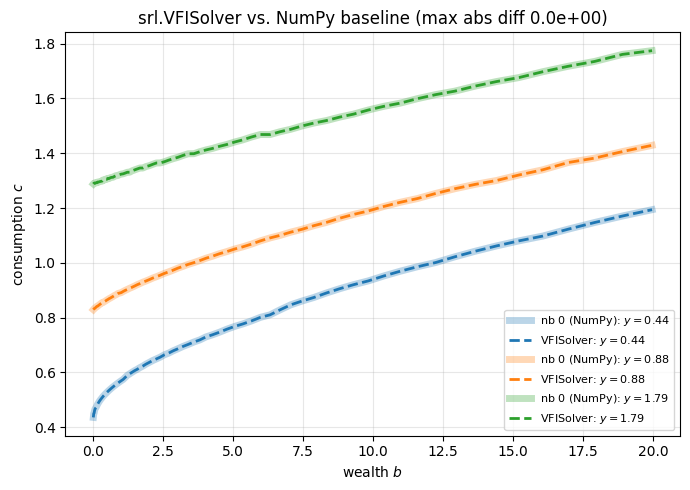

In [18]:
max_abs_lib = float(jnp.max(jnp.abs(c_policy_lib - jnp.asarray(c_policy_np))))
print(f"max |c_VFISolver - c_NumPy| = {max_abs_lib:.2e}")

fig, ax = plt.subplots(figsize=(7, 5))
for j in range(n_y):
    line, = ax.plot(b_grid[mask], c_policy_np[mask, j], lw=5, alpha=0.3,
                    label=f"nb 0 (NumPy): $y={float(e_grid[j]):.2f}$")
    ax.plot(b_grid[mask], c_policy_lib[mask, j], lw=2, ls="--", color=line.get_color(),
            label=f"VFISolver: $y={float(e_grid[j]):.2f}$")
ax.set_xlabel("wealth $b$")
ax.set_ylabel("consumption $c$")
ax.set_title(f"srl.VFISolver vs. NumPy baseline (max abs diff {max_abs_lib:.1e})")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## What we did, and what's next

We re-solved notebook 0's household problem in JAX, by hand (`vmap` + `jit`)
and via `srl.VFISolver`, and both reproduce the NumPy consumption policy. The
economics never moved; we only changed the engine, and previewed `grad`.

**Notebook 2** changes the *method* instead of the tooling: it throws away the
Bellman operator and maximizes lifetime utility directly by gradient ascent on
the policy (the policy gradient), checked once more against this same answer.

## Exercises

1. **Autodiff vs. finite differences.** For the marginal utility check above,
   shrink the finite-difference step $h$ from $10^{-2}$ down to $10^{-8}$ and
   plot the error against `jax.grad`. Finite differences improve, then *worsen*
   as rounding dominates; `jax.grad` is exact at every $h$ because it never
   takes a difference. A worked version is below.
2. **`vmap` a comparative static.** Use `jax.vmap` to solve the model for a
   sweep of bond prices $q$ at once (hint: make `q` an argument and vectorize
   `bellman_step` over it). How does the consumption policy shift as $q$ rises
   (the interest rate falls)?

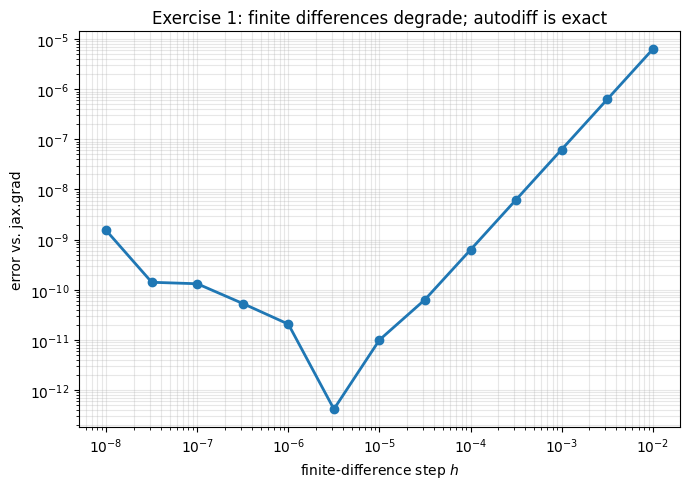

In [19]:
hs = np.logspace(-2, -8, 13)
errs = [abs((u(c0 + h) - u(c0 - h)) / (2 * h) - float(du(c0))) for h in hs]

fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(hs, errs, "o-", lw=2)
ax.set_xlabel("finite-difference step $h$")
ax.set_ylabel("error vs. jax.grad")
ax.set_title("Exercise 1: finite differences degrade; autodiff is exact")
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()